In [3]:
using IonSim
using QuantumOptics
using PyPlot

In [4]:
# ---------------------------------------------------------
# 1. Setup the Physical System
# ---------------------------------------------------------
# We need a higher Hilbert space dimension (N=20) to simulate displacements
# If N is too low, the wavepacket will "hit the wall" of the simulation array.
trap_freq = 1e6 # 1 MHz trap frequency
# mode = VibrationalMode(1, [0,0,1], δν=trap_freq, N=20) 
ion = Ca40([("S1/2", -1/2, "g"), ("D5/2", -1/2, "e")])
chain = LinearChain(ions=[ion], comfrequencies=(x=3e6, y=3e6, z=trap_freq),selectedmodes=(; z=[1]))

mode_z = zmodes(chain)[1] # Get the first (and only) Z-mode of the chain
mode_z.N = 10

# ---------------------------------------------------------
# 2. Define the Bichromatic Laser Field
# ---------------------------------------------------------
# To create the displacement, we need TWO lasers (or one laser with two tones).
# Both need to be parallel to the Z-axis (k=ẑ) to push the ion.

k_vec = (x̂ + ẑ) / √2
ϵ_vec = (x̂ + ŷ) / √2

laser_intensity = 2e7 # Adjust this to push the ion faster/slower
transition_λ = 729e-9 # Wavelength is REQUIRED to calculate the Lamb-Dicke parameter!
B_field = 1e-13

# Laser 1: Red Sideband (Detuned by -ω_m)
zeeman_offset = zeemanshift(ion, "e", B_field) - zeemanshift(ion, "g", B_field)
println("Zeeman Offset: ", zeeman_offset, " Hz")

# Laser 1: Red Sideband 
# Center on the Zeeman shifted carrier, then subtract the trap frequency
L_red = Laser(Δ = zeeman_offset - trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Laser 2: Blue Sideband 
# Center on the Zeeman shifted carrier, then add the trap frequency
L_blue = Laser(Δ = zeeman_offset + trap_freq, I = laser_intensity, k=k_vec, ϵ=ϵ_vec, λ=transition_λ)

# Create the Trap with both lasers shining on the ion

trap = Chamber(iontrap=chain, B=B_field, Bhat=ẑ, lasers=[L_red, L_blue])

# ---------------------------------------------------------
# 3. Initialize the State
# ---------------------------------------------------------
# Start with Ion in |g> and Motion in |0>
mode = zmodes(trap)[1]
ψ_ion = normalize(ion["g"] + ion["e"])
# ψ_mode = fockstate(mode[1].basis, 0)
ψ_mode = fockstate(mode, 0)
ψ_initial = ψ_ion ⊗ ψ_mode


# ---------------------------------------------------------
# 4. Run the Simulation
# ---------------------------------------------------------
# Generate the Hamiltonian
h = hamiltonian(trap, timescale=1e-6, rwa_cutoff=Inf)
# Apply the two lasers for 15 microseconds
tspan = 0:0.5:100.0 
println("Simulating bichromatic displacement...")
tout, sol = timeevolution.schroedinger_dynamic(tspan, ψ_initial, h)

# Get the final combined quantum state (Ion ⊗ Motion)
final_state = sol[end]

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)


Zeeman Offset: 0.0005611952854826817 Hz
Simulating bichromatic displacement...


┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase C:\Users\jewoo\.julia\packages\SciMLBase\pzpcE\src\integrator_interface.jl:626


81×81 Matrix{Float64}:
 4.03776e-15  8.89675e-15  1.92148e-14  …  8.89363e-15  4.03631e-15
 8.89645e-15  1.96023e-14  4.23362e-14     1.95954e-14  8.89325e-15
 1.92135e-14  4.23347e-14  9.14327e-14     4.23199e-14  1.92066e-14
 4.06734e-14  8.96191e-14  1.93555e-13     8.95877e-14  4.06588e-14
 8.43973e-14  1.8596e-13   4.01627e-13     1.85895e-13  8.43669e-14
 1.71657e-13  3.78226e-13  8.16875e-13  …  3.78093e-13  1.71595e-13
 3.42221e-13  7.54045e-13  1.62855e-12     7.5378e-13   3.42098e-13
 6.68755e-13  1.47352e-12  3.18245e-12     1.47301e-12  6.68515e-13
 1.28098e-12  2.82249e-12  6.09588e-12     2.8215e-12   1.28052e-12
 2.40508e-12  5.29932e-12  1.14452e-11     5.29747e-12  2.40422e-12
 ⋮                                      ⋱               ⋮
 1.27773e-12  2.81533e-12  6.08041e-12     2.81434e-12  1.27727e-12
 6.67005e-13  1.46967e-12  3.17413e-12     1.46916e-12  6.66766e-13
 3.41299e-13  7.52012e-13  1.62416e-12     7.51749e-13  3.41176e-13
 1.7118e-13   3.77176e-13  8.14608e

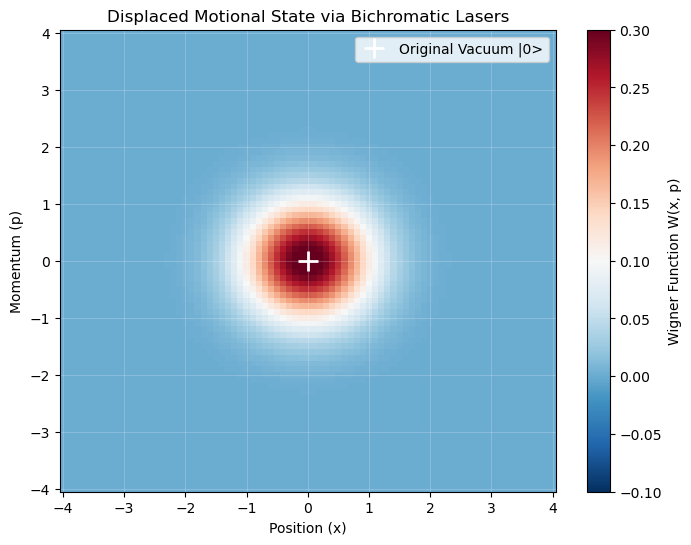

In [5]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)


In [6]:
# Create a "Do Nothing" operator for the ion
I_spin = identityoperator(ion["g"].basis)

# Create the pure motional push
b = FockBasis(30)
D_motion = displace(b, 0.5)

# Combine them: "Do nothing to spin AND push the motion"
D_system = I_spin ⊗ D_motion

# Apply to the full joint state
displaced_final_state = D_system * sol[end]

QuantumInterface.IncompatibleBases: QuantumInterface.IncompatibleBases()

In [7]:
# 1. Grab the exact mode object used in the simulation (no generic FockBasis!)
sim_mode = zmodes(trap)[1]
a = 0.5

# 2. Build the displacement operator using the IonSim mode
# IonSim has a built-in displace() method specifically for VibrationalModes
D_motion = IonSim.displace(sim_mode, a)

# 3. Create a "Do Nothing" operator for the ion's spin
I_spin = identityoperator(ion["g"].basis)

# 4. Combine them into a full system operator (Spin ⊗ Motion)
D_system = I_spin ⊗ D_motion

# 5. Apply the operator to the state (The bases now match perfectly!)
displaced_final_state = D_system * sol[end]

Ket(dim=22)
  basis: [⁴⁰Ca ⊗ VibrationalMode(ν=1.0e6, axis=ẑ, N=10)]
  0.6223311167312586 - 0.00062927937634445im
   0.625713812918067 - 0.00052706596991999im
  0.3110584777635807 - 0.00029070278836556im
 0.31278902186513635 - 0.00030693481842266im
 0.10993773409790074 - 9.435869392959e-5im
 0.11056344769478949 - 0.00012381277708875im
 0.03172525360506608 - 2.482063691045e-5im
 0.03190989118975112 - 4.014249072552e-5im
 0.00792854081543455 - 5.60365829649e-6im
 0.00797570375968207 - 1.113220868719e-5im
                     ⋮
 0.00036387623319983 - 6.0772066025e-7im
   6.831771193395e-5 - 3.293127109e-8im
   6.875055871935e-5 - 1.2421328674e-7im
   1.207275885482e-5 - 4.92321554e-9im
   1.215081384535e-5 - 2.360819276e-8im
    2.01057794849e-6 - 6.7158496e-10im
    2.02383769368e-6 - 4.20657359e-9im
     3.2455940521e-7 - 8.352701e-11im
     3.2674389726e-7 - 7.2526999e-10im

In [8]:
final_state = displaced_final_state

# ---------------------------------------------------------
# 5. Extract and Plot the Wigner Function
# ---------------------------------------------------------
# The state 'final_state' contains BOTH the ion and the motion.
# We must "trace out" (ignore) the ion's internal state to look only at the motion.
# In IonSim, the order is (Ion_Basis ⊗ Mode_Basis), so the mode is subsystem 2.
rho_motional = ptrace(final_state, 1)

# FIX: Convert IonSim's VibrationalMode basis to a standard QuantumOptics FockBasis
# We used N=20 for our simulation, so we create a FockBasis of the same size.
b_fock = FockBasis(10)
rho_fock = DenseOperator(b_fock, rho_motional.data)

# Define the phase space grid (Position 'x' vs Momentum 'p')
x_vec = -4.0:0.1:4.0
p_vec = -4.0:0.1:4.0

# Calculate the Wigner quasiprobability distribution using the converted state
W = wigner(rho_fock, x_vec, p_vec)

81×81 Matrix{Float64}:
 -3.01556e-19  -1.9139e-17   -6.81748e-17  …  -1.92166e-17  -3.45553e-19
  1.54778e-17  -8.10115e-18  -8.20786e-17     -8.2754e-18    1.53817e-17
  6.76265e-17   5.5758e-17   -2.84634e-17      5.53803e-17   6.74234e-17
  2.13231e-16   2.70636e-16   2.54878e-16      2.69845e-16   2.12815e-16
  5.81736e-16   8.70519e-16   1.17809e-15      8.68912e-16   5.80912e-16
  1.45259e-15   2.3802e-15    3.70086e-15  …   2.37703e-15   1.45101e-15
  3.40461e-15   5.92128e-15   9.94321e-15      5.91523e-15   3.40165e-15
  7.59438e-15   1.37964e-14   2.43783e-14      1.37851e-14   7.58901e-15
  1.62617e-14   3.05723e-14   5.6089e-14       3.05519e-14   1.62522e-14
  3.36265e-14   6.50393e-14   1.22923e-13      6.50032e-14   3.36102e-14
  ⋮                                        ⋱                 ⋮
  7.16379e-11   1.57766e-10   3.40606e-10      1.57711e-10   7.16125e-11
  4.30245e-11   9.47675e-11   2.04627e-10      9.47347e-11   4.30092e-11
  2.53248e-11   5.57922e-11   1.2049e-

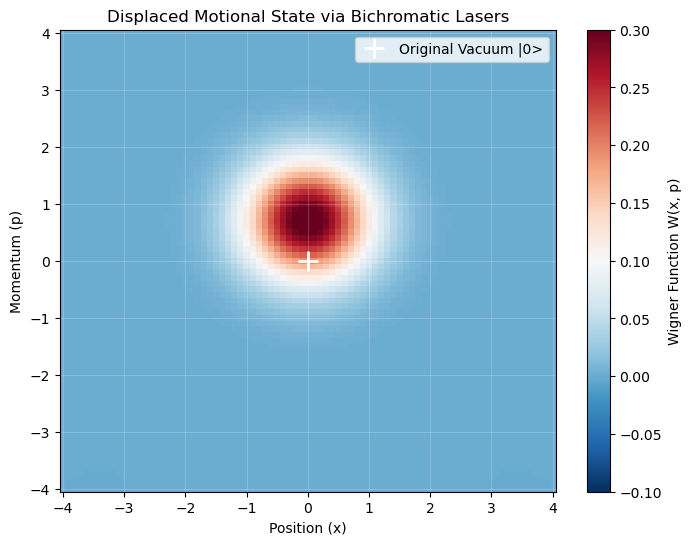

In [9]:
fig = figure(figsize=(8, 6))
PyPlot.pcolormesh(x_vec, p_vec, W, cmap="RdBu_r", vmin=-0.1, vmax=0.3, shading="nearest")
PyPlot.colorbar(label="Wigner Function W(x, p)")

# Add a marker where the vacuum state (0,0) originally was
PyPlot.plot([0], [0], "w+", markersize=15, markeredgewidth=2, label="Original Vacuum |0>")

PyPlot.xlabel("Position (x)")
PyPlot.ylabel("Momentum (p)")
PyPlot.title("Displaced Motional State via Bichromatic Lasers")
PyPlot.legend()
PyPlot.grid(color="white", alpha=0.2)

# Display the figure safely in Jupyter (removed show() to prevent the device warning)
display(fig)
